# Lab 8: Designed Your Own CNN

## Objective
Build and train a custom Convolutional Neural Network (CNN) to classify corn leaf images into **four disease categories** using the dataset prepared in Lab 7.

## Dataset
The dataset is structured into `train/`, `validation/`, and `test/` directories, each containing four subfolders:
- `Cercospora`
- `common_rust`
- `healthy`
- `northern_leaf_blight`

## Model Architecture (Implemented)
The CNN consists of:
- **Conv2D** layers with increasing filters (32 → 64 → 128 → 128), each followed by **MaxPooling2D**.
- **Flatten** layer.
- **Dense** layer with 512 units and ReLU activation.
- **Output Dense** layer with 4 units and Softmax activation (multiclass classification).

> **Note:** The lab description suggested a different architecture (with BatchNormalization, Dropout, and sigmoid output for binary classification). This notebook implements a custom architecture chosen by the student.

## Compilation & Training
- **Loss:** `categorical_crossentropy` (multiclass)
- **Optimizer:** RMSprop with learning rate 1e-4
- **Metrics:** Accuracy
- **Epochs:** 50
- **Callbacks:** ModelCheckpoint to save the best model based on validation loss.

## Evaluation
After training, the model is evaluated on the test set using a confusion matrix and classification report.

In [1]:
# Import necessary libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

## 1. Define Paths and Checkpoints

In [2]:
# Directory paths for training, validation, and test sets
train_dir = r'C:\Users\PMYLS\Documents\MachineLearningLaB\Computervision\train'
validation_dir = r'C:\Users\PMYLS\Documents\MachineLearningLaB\Computervision\validation'
test_dir = r'C:\Users\PMYLS\Documents\MachineLearningLaB\Computervision\test'

# Checkpoint file pattern
checkpoints = r'C:\Users\PMYLS\Documents\MachineLearningLaB\Computervision\E1-cp-{epoch:04d}-loss{val_loss:.2f}.h5'

## 2. Build the CNN Model
The model architecture is defined using Keras Sequential API.

In [4]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(4, activation='softmax')   # 4 classes
])

In [4]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 127, 127, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 62, 62, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 60, 60, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 30, 30, 128)      0

## 3. Compile the Model

In [5]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=1e-4),
    metrics=['acc']
)

## 4. Prepare Data Generators
Images are rescaled to [0,1] and loaded in batches of 32 with target size 256×256.

In [6]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_directory(
    validation_dir,
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical'
)

Found 1600 images belonging to 4 classes.
Found 252 images belonging to 4 classes.


## 5. Set Up ModelCheckpoint Callback
Saves the model whenever validation loss improves.

In [7]:
checkpoint = ModelCheckpoint(
    checkpoints,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)
callbacks = [checkpoint]

## 6. Train the Model
Train for 50 epochs with validation monitoring.

In [8]:
step_size_train = train_generator.n // train_generator.batch_size

model_history = model.fit(
    train_generator,
    validation_data=validation_generator,
    steps_per_epoch=step_size_train,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
50/50 [==============================] - ETA: 0s - loss: 0.8991 - acc: 0.5956
Epoch 1: val_loss improved from inf to 0.52399, saving model to C:\\Users\\PMYLS\\Documents\\MachineLearningLaB\\Computervision\E1-cp-0001-loss0.52.h5
50/50 [==============================] - 125s 2s/step - loss: 0.8991 - acc: 0.5956 - val_loss: 0.5240 - val_acc: 0.7540
Epoch 2/50
50/50 [==============================] - ETA: 0s - loss: 0.5219 - acc: 0.7681
Epoch 2: val_loss did not improve from 0.52399
50/50 [==============================] - 108s 2s/step - loss: 0.5219 - acc: 0.7681 - val_loss: 0.6546 - val_acc: 0.7222
Epoch 3/50
50/50 [==============================] - ETA: 0s - loss: 0.4421 - acc: 0.7944
Epoch 3: val_loss improved from 0.52399 to 0.39630, saving model to C:\\Users\\PMYLS\\Documents\\MachineLearningLaB\\Computervision\E1-cp-0003-loss0.40.h5
50/50 [==============================] - 117s 2s/step - loss: 0.4421 - acc: 0.7944 - val_loss: 0.3963 - val_acc: 0.8175
Epoch 4/50
50/50 [==

## 7. Training History
Display the recorded metrics.

In [9]:
model_history.history

{'loss': [0.8991315364837646,
  0.5218632817268372,
  0.44210097193717957,
  0.36315402388572693,
  0.32702770829200745,
  0.31236883997917175,
  0.2563871145248413,
  0.24639655649662018,
  0.20295129716396332,
  0.20659498870372772,
  0.16926661133766174,
  0.15833213925361633,
  0.15656745433807373,
  0.13391883671283722,
  0.136449933052063,
  0.11362958699464798,
  0.11325452476739883,
  0.09392812103033066,
  0.07801154255867004,
  0.08249180018901825,
  0.05772138759493828,
  0.06885979324579239,
  0.043587084859609604,
  0.05160747095942497,
  0.03023015893995762,
  0.07037549465894699,
  0.02524753101170063,
  0.03078349679708481,
  0.017232036218047142,
  0.038109734654426575,
  0.019679319113492966,
  0.017264872789382935,
  0.013290523551404476,
  0.009765658527612686,
  0.02015559934079647,
  0.025699110701680183,
  0.013596908189356327,
  0.0009820408886298537,
  0.019481725990772247,
  0.027429476380348206,
  0.0006507757352665067,
  0.010737313888967037,
  0.02178677357

## 8. Visualize Training Curves
Accuracy and loss plots for training and validation sets.

In [10]:
# Extract metrics from history
acc = model_history.history['acc']
val_acc = model_history.history['val_acc']
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']
epochs = range(1, len(acc) + 1)

# Plot accuracy
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.figure()

# Plot loss
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Save the figure (optional)
# plt.savefig(r'C:\Users\PMYLS\Documents\MachineLearningLaB\Computervision\model_Accuracy.png')

## 9. Save the Trained Model

In [11]:
# Save the entire model as a SavedModel directory
model.save(r'C:\Users\PMYLS\Documents\MachineLearningLaB\Computervision')

INFO:tensorflow:Assets written to: C:\Users\PMYLS\Documents\MachineLearningLaB\Computervision\assets


INFO:tensorflow:Assets written to: C:\Users\PMYLS\Documents\MachineLearningLaB\Computervision\assets


## 10. Evaluate on Test Set
Generate predictions on the test data, compute confusion matrix and classification report.

Found 200 images belonging to 4 classes.
7/7 [==============================] - 4s 392ms/step


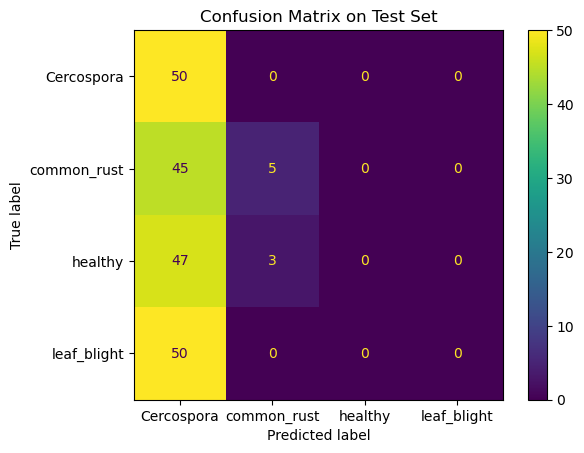

              precision    recall  f1-score   support

  Cercospora       0.26      1.00      0.41        50
 common_rust       0.62      0.10      0.17        50
     healthy       0.00      0.00      0.00        50
 leaf_blight       0.00      0.00      0.00        50

    accuracy                           0.28       200
   macro avg       0.22      0.28      0.15       200
weighted avg       0.22      0.28      0.15       200



C:\Users\PMYLS\anaconda3\envs\machinelearning\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\PMYLS\anaconda3\envs\machinelearning\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\PMYLS\anaconda3\envs\machinelearning\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

In [5]:
# Create test generator (no shuffling to preserve order)
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256, 256),
    batch_size=32,
    shuffle=False,
    class_mode='categorical'
)

# Get true labels and predictions
true_labels = test_generator.labels
pred_probs = model.predict(test_generator)
pred_labels = np.argmax(pred_probs, axis=1)

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Cercospora', 'common_rust', 'healthy', 'leaf_blight']
)
disp.plot()
plt.title('Confusion Matrix on Test Set')
plt.show()

# Classification report
print(classification_report(
    true_labels,
    pred_labels,
    target_names=['Cercospora', 'common_rust', 'healthy', 'leaf_blight']
))